# Part 4 — Evaluation and Bias Analysis

### Notebook 04 — Evaluation & Bias Analysis
### Sovereign Credit Rating Prediction | George Nyatang | 2025

**This notebook produces:**
1. Confusion matrices for all 3 models
2. Per-class precision / recall / F1
3. ROC-AUC (one-vs-rest)
4. **Bias analysis** — African vs. Benchmark model error gap
5. Rating change prediction accuracy (upgrade / stable / downgrade)
6. Time-series of predictions vs. true labels per country
7. Final publication-ready comparison table

In [53]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn

import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, roc_auc_score,
                              ConfusionMatrixDisplay)

warnings.filterwarnings('ignore')
np.random.seed(42)

RESULTS = Path('results')
RESULTS.mkdir(exist_ok=True)

CLASS_NAMES  = ['Default', 'Junk', 'Inv. Grade']
AFRICA       = ['South Africa','Kenya','Ghana','Egypt','Nigeria','Ethiopia','Botswana','Morocco','Zambia']
COLORS       = {'Default': '#c0392b', 'Junk': '#e67e22', 'Inv. Grade': '#27ae60'}
MODEL_COLORS = {'Ordered Logistic': '#2980b9', 'XGBoost': '#8e44ad', 'LSTM': '#16a085'}

# Load predictions from notebook 03
df = pd.read_csv(RESULTS/'test_predictions.csv', parse_dates=['date'])
print(f'Loaded predictions: {df.shape}')
print(f'Countries: {df.country.unique()}')
print(f'Date range: {df.date.min().date()} → {df.date.max().date()}')
df.head(30)

Loaded predictions: (612, 16)
Countries: ['Botswana' 'Brazil' 'China' 'Egypt' 'Ethiopia' 'Germany' 'Ghana' 'India'
 'Japan' 'Kenya' 'Mexico' 'Morocco' 'Nigeria' 'South Africa'
 'United Kingdom' 'United States' 'Zambia']
Date range: 2022-01-01 → 2024-12-01


,country,date,region,future_class,pred_xgb,prob_default_xgb,prob_junk_xgb,prob_invgrade_xgb,pred_ord,prob_default_ord,prob_junk_ord,prob_invgrade_ord,pred_lstm,prob_default_lstm,prob_junk_lstm,prob_invgrade_lstm
0,Botswana,2022-01-01,Africa,2,2,0.000902,0.001586,0.997512,2,0.1,0.1,0.7,NaN,NaN,NaN,NaN
1,Botswana,2022-02-01,Africa,2,2,0.000957,0.001683,0.997360,2,0.1,0.1,0.7,NaN,NaN,NaN,NaN
2,Botswana,2022-03-01,Africa,2,2,0.000957,0.001683,0.997360,2,0.1,0.1,0.7,NaN,NaN,NaN,NaN
3,Botswana,2022-04-01,Africa,2,2,0.000976,0.001716,0.997309,2,0.1,0.1,0.7,NaN,NaN,NaN,NaN
4,Botswana,2022-05-01,Africa,2,2,0.000976,0.001716,0.997309,2,0.1,0.1,0.7,NaN,NaN,NaN,NaN
5,Botswana,2022-06-01,Africa,2,2,0.000976,0.001716,0.997309,2,0.1,0.1,0.7,NaN,NaN,NaN,NaN
6,Botswana,2022-07-01,Africa,2,2,0.000976,0.001716,0.997309,2,0.1,0.1,0.7,NaN,NaN,NaN,NaN
7,Botswana,2022-08-01,Africa,2,2,0.000976,0.001716,0.997309,2,0.1,0.1,0.7,NaN,NaN,NaN,NaN
8,Botswana,2022-09-01,Africa,2,2,0.000976,0.001716,0.997309,2,0.1,0.1,0.7,NaN,NaN,NaN,NaN
9,Botswana,2022-10-01,Africa,2,2,0.000976,0.001716,0.997309,2,0.1,0.1,0.7,NaN,NaN,NaN,NaN


## 1. Confusion Matrices — All 3 Models

Available columns:
['country', 'date', 'region', 'future_class', 'pred_xgb', 'prob_default_xgb', 'prob_junk_xgb', 'prob_invgrade_xgb', 'pred_ord', 'prob_default_ord', 'prob_junk_ord', 'prob_invgrade_ord', 'pred_lstm', 'prob_default_lstm', 'prob_junk_lstm', 'prob_invgrade_lstm']
Detected columns:
Ordered Logistic: pred_ord
XGBoost: pred_xgb
LSTM: pred_lstm


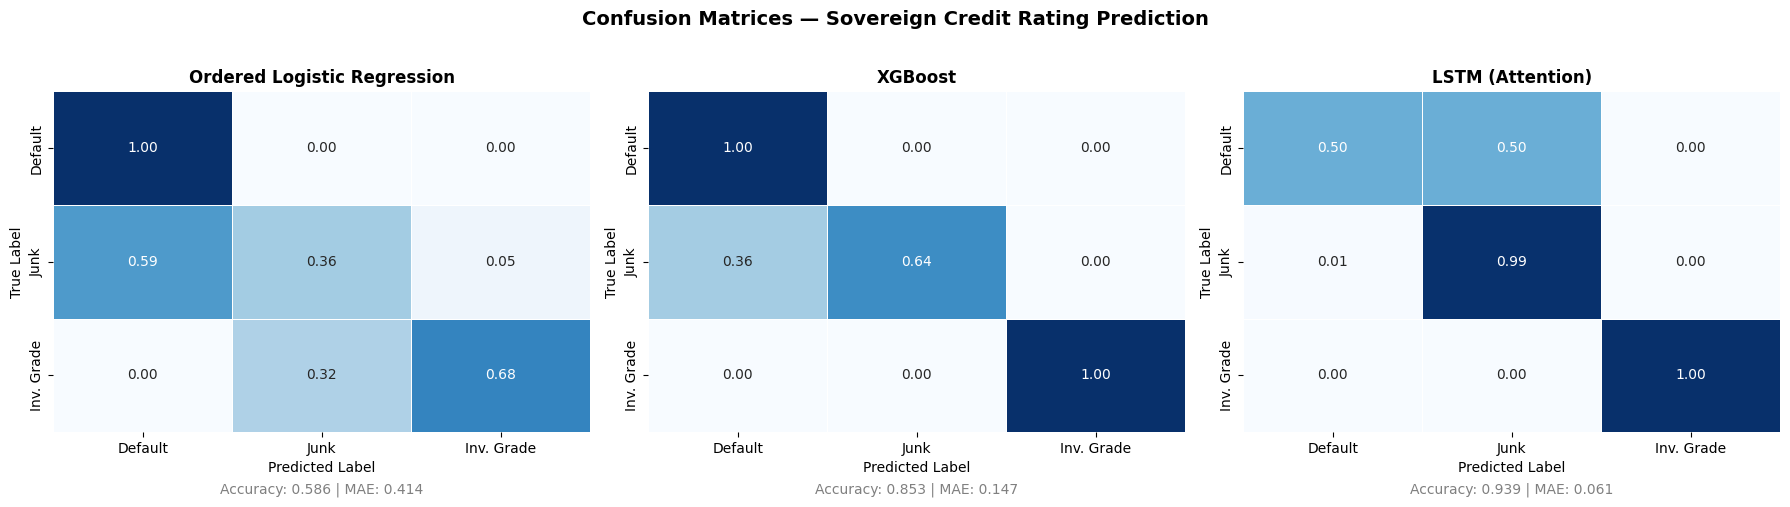

Rows used for comparison: 408


In [58]:
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

CLASS_NAMES = ['Default', 'Junk', 'Inv. Grade']

# --- auto-detect prediction column names ---
print("Available columns:")
print(results_df.columns.tolist())

ord_col = next((c for c in ['pred_ord', 'pred_ordered_logistic'] if c in results_df.columns), None)
xgb_col = next((c for c in ['pred_xgb', 'pred_xgboost'] if c in results_df.columns), None)
lstm_col = next((c for c in ['pred_lstm'] if c in results_df.columns), None)

print("Detected columns:")
print("Ordered Logistic:", ord_col)
print("XGBoost:", xgb_col)
print("LSTM:", lstm_col)

if ord_col is None or xgb_col is None or lstm_col is None:
    raise ValueError("Could not find one or more prediction columns in results_df.")

def plot_confusion_matrix(y_true, y_pred, title, ax, normalize=True):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

    if normalize:
        cm_plot = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        fmt = ".2f"
    else:
        cm_plot = cm
        fmt = "d"

    sns.heatmap(
        cm_plot,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        linewidths=0.5,
        ax=ax,
        cbar=False
    )

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

    acc = accuracy_score(y_true, y_pred)
    mae = np.mean(np.abs(np.array(y_pred) - np.array(y_true)))

    ax.text(
        0.5, -0.18,
        f'Accuracy: {acc:.3f} | MAE: {mae:.3f}',
        transform=ax.transAxes,
        ha='center',
        fontsize=10,
        color='gray'
    )

# use only rows where all 3 models have predictions
df_full = results_df.dropna(subset=[ord_col, xgb_col, lstm_col]).copy()

df_full[ord_col] = df_full[ord_col].astype(int)
df_full[xgb_col] = df_full[xgb_col].astype(int)
df_full[lstm_col] = df_full[lstm_col].astype(int)
df_full['future_class'] = df_full['future_class'].astype(int)

y_true = df_full['future_class'].values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    "Confusion Matrices — Sovereign Credit Rating Prediction",
    fontsize=14,
    fontweight="bold",
    y=1.02
)

plot_confusion_matrix(y_true, df_full[ord_col].values, "Ordered Logistic Regression", axes[0])
plot_confusion_matrix(y_true, df_full[xgb_col].values, "XGBoost", axes[1])
plot_confusion_matrix(y_true, df_full[lstm_col].values, "LSTM (Attention)", axes[2])

plt.tight_layout()
plt.show()

print("Rows used for comparison:", df_full.shape[0])

In [ ]:
print(results_df.columns.tolist())

## 2. Full Metrics Table

In [59]:
def compute_metrics(y_true, y_pred, y_proba=None, model_name=''):
    acc  = accuracy_score(y_true, y_pred)
    mae  = np.mean(np.abs(np.array(y_pred) - np.array(y_true)))
    report = classification_report(y_true, y_pred,
                                    target_names=CLASS_NAMES,
                                    output_dict=True)
    row = {
        'Model':    model_name,
        'Accuracy': round(acc, 4),
        'MAE':      round(mae, 4),
        'F1 (Default)':    round(report['Default']['f1-score'], 4),
        'F1 (Junk)':       round(report['Junk']['f1-score'], 4),
        'F1 (Inv.Grade)':  round(report['Inv. Grade']['f1-score'], 4),
        'Macro F1':        round(report['macro avg']['f1-score'], 4),
        'Weighted F1':     round(report['weighted avg']['f1-score'], 4),
    }
    if y_proba is not None and y_proba.ndim == 2 and y_proba.shape[1] == 3:
        try:
            auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
            row['AUC-OvR'] = round(auc, 4)
        except:
            row['AUC-OvR'] = None
    return row

metrics_rows = []

# Ordered logistic — rebuild proba array from saved CSV probabilities
metrics_rows.append(compute_metrics(
    y_true, df_full['pred_ord'].values,
    model_name='Ordered Logistic Regression'
))

# XGBoost
xgb_proba = df_full[['prob_default_xgb','prob_junk_xgb','prob_invgrade_xgb']].values
metrics_rows.append(compute_metrics(
    y_true, df_full['pred_xgb'].values,
    y_proba=xgb_proba,
    model_name='XGBoost'
))

# LSTM
lstm_proba = df_full[['prob_default_lstm','prob_junk_lstm','prob_invgrade_lstm']].values
metrics_rows.append(compute_metrics(
    y_true, df_full['pred_lstm'].values,
    y_proba=lstm_proba,
    model_name='LSTM (Attention)'
))

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(RESULTS/'full_metrics_table.csv', index=False)
print('=== FULL METRICS TABLE ===')
print(metrics_df.to_string(index=False))

=== FULL METRICS TABLE ===
                      Model  Accuracy    MAE  F1 (Default)  F1 (Junk)  F1 (Inv.Grade)  Macro F1  Weighted F1  AUC-OvR
Ordered Logistic Regression    0.5858 0.4142        0.4923     0.4192          0.7879    0.5665       0.6013      NaN
                    XGBoost    0.8529 0.1471        0.6154     0.7826          1.0000    0.7993       0.8652   0.9354
           LSTM (Attention)    0.9387 0.0613        0.6575     0.9304          1.0000    0.8626       0.9310   0.9435


## 3. Bias Analysis — African vs. Benchmark

**Core research question:** Does the model perform better or worse on African countries compared to global benchmark?

The **Bias Gap = Africa MAE − Benchmark MAE**.  
A positive gap means the model is less accurate for African countries (suggesting structural difficulty).  
We compare this gap across all 3 models and against a naive baseline (always predict Investment Grade).

In [61]:
def regional_metrics(df_preds, pred_col, true_col='future_class'):
    results = []
    for region in ['Africa', 'Benchmark']:
        sub = df_preds[df_preds['region'] == region].dropna(subset=[pred_col])
        yt = sub[true_col].values
        yp = sub[pred_col].values.astype(int)
        results.append({
            'Region':   region,
            'N':        len(yt),
            'Accuracy': round(accuracy_score(yt, yp), 4),
            'MAE':      round(np.mean(np.abs(yp - yt)), 4),
            'F1 Macro': round(float(pd.DataFrame(
                classification_report(yt, yp, output_dict=True)
            ).loc['f1-score','macro avg']), 4)
        })
    df_r = pd.DataFrame(results)
    bias_gap_mae = (df_r[df_r.Region=='Africa']['MAE'].values[0] -
                    df_r[df_r.Region=='Benchmark']['MAE'].values[0])
    bias_gap_acc = (df_r[df_r.Region=='Benchmark']['Accuracy'].values[0] -
                    df_r[df_r.Region=='Africa']['Accuracy'].values[0])
    return df_r, round(bias_gap_mae, 4), round(bias_gap_acc, 4)

print('=== REGIONAL BREAKDOWN ===')
bias_summary = []

for model_col, model_name in [
    ('pred_ord', 'Ordered Logistic'), # Corrected column name
    ('pred_xgb', 'XGBoost'),          # Corrected column name
    ('pred_lstm', 'LSTM'),
]:
    reg_df, gap_mae, gap_acc = regional_metrics(df_full, model_col)
    print(f'\n--- {model_name} ---')
    print(reg_df.to_string(index=False))
    print(f'  Bias Gap (MAE: Africa − Benchmark): {gap_mae:+.4f}')
    print(f'  Bias Gap (Acc: Bench − Africa):     {gap_acc:+.4f}')
    bias_summary.append({'Model': model_name, 'Bias Gap MAE': gap_mae, 'Bias Gap Acc': gap_acc})

# Naive baseline: always predict majority class
majority = int(pd.Series(y_true).mode()[0])
df_full['pred_naive'] = majority
naive_df, naive_gap_mae, naive_gap_acc = regional_metrics(df_full, 'pred_naive')
print(f'\n--- Naive Baseline (always class {majority}) ---')
print(naive_df.to_string(index=False))
bias_summary.append({'Model': f'Naive (class={majority})', 'Bias Gap MAE': naive_gap_mae, 'Bias Gap Acc': naive_gap_acc})

bias_df = pd.DataFrame(bias_summary)
bias_df.to_csv(RESULTS/'bias_analysis.csv', index=False)

=== REGIONAL BREAKDOWN ===

--- Ordered Logistic ---
   Region   N  Accuracy    MAE  F1 Macro
   Africa 216    0.5046 0.4954    0.5861
Benchmark 192    0.6771 0.3229    0.6050
  Bias Gap (MAE: Africa − Benchmark): +0.1725
  Bias Gap (Acc: Bench − Africa):     +0.1725

--- XGBoost ---
   Region   N  Accuracy    MAE  F1 Macro
   Africa 216    0.7222 0.2778    0.7841
Benchmark 192    1.0000 0.0000    1.0000
  Bias Gap (MAE: Africa − Benchmark): +0.2778
  Bias Gap (Acc: Bench − Africa):     +0.2778

--- LSTM ---
   Region   N  Accuracy    MAE  F1 Macro
   Africa 216    0.8843 0.1157     0.859
Benchmark 192    1.0000 0.0000     1.000
  Bias Gap (MAE: Africa − Benchmark): +0.1157
  Bias Gap (Acc: Bench − Africa):     +0.1157

--- Naive Baseline (always class 2) ---
   Region   N  Accuracy    MAE  F1 Macro
   Africa 216    0.1111 1.1111    0.0667
Benchmark 192    0.8750 0.1250    0.4667


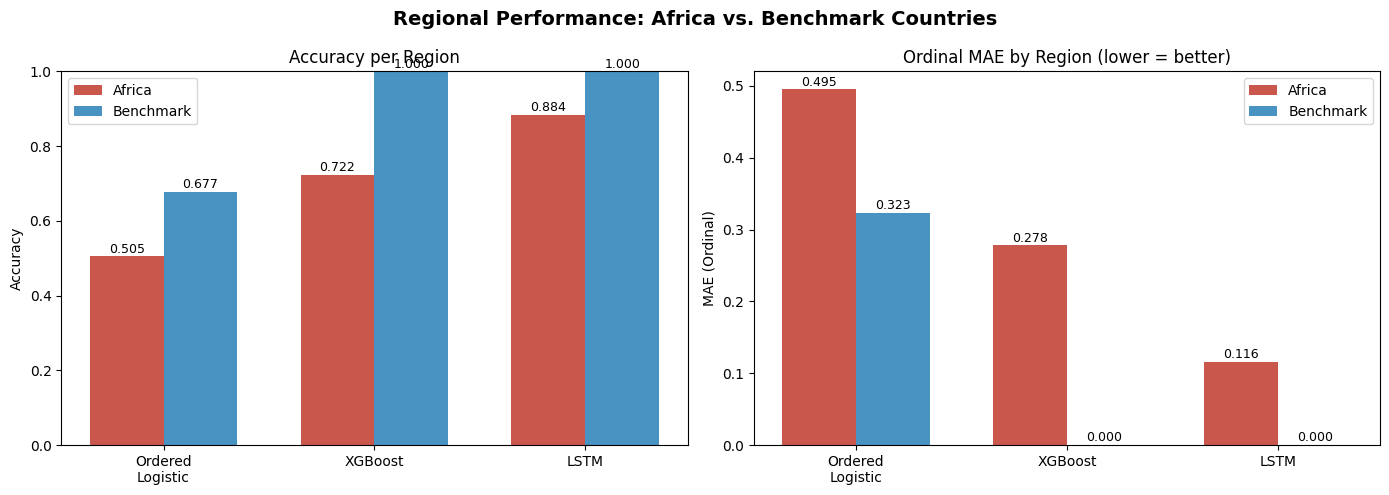

In [67]:
# Plot: Accuracy by region per model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Regional Performance: Africa vs. Benchmark Countries',
             fontsize=14, fontweight='bold')

models = ['pred_ord','pred_xgb','pred_lstm']
model_labels = ['Ordered\nLogistic','XGBoost','LSTM']

africa_acc, bench_acc = [], []
africa_mae, bench_mae = [], []

for m in models:
    reg, _, _ = regional_metrics(df_full, m)
    africa_acc.append(reg[reg.Region=='Africa']['Accuracy'].values[0])
    bench_acc.append(reg[reg.Region=='Benchmark']['Accuracy'].values[0])
    africa_mae.append(reg[reg.Region=='Africa']['MAE'].values[0])
    bench_mae.append(reg[reg.Region=='Benchmark']['MAE'].values[0])

x = np.arange(len(models))
w = 0.35

# Accuracy subplot
axes[0].bar(x - w/2, africa_acc, w, label='Africa', color='#c0392b', alpha=0.85)
axes[0].bar(x + w/2, bench_acc, w, label='Benchmark', color='#2980b9', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(model_labels)
axes[0].set_ylabel('Accuracy'); axes[0].set_title('Accuracy per Region')
axes[0].legend(); axes[0].set_ylim(0, 1)
for i, (a, b) in enumerate(zip(africa_acc, bench_acc)):
    axes[0].text(i - w/2, a + 0.01, f'{a:.3f}', ha='center', fontsize=9)
    axes[0].text(i + w/2, b + 0.01, f'{b:.3f}', ha='center', fontsize=9)

# MAE subplot
axes[1].bar(x - w/2, africa_mae, w, label='Africa', color='#c0392b', alpha=0.85)
axes[1].bar(x + w/2, bench_mae, w, label='Benchmark', color='#2980b9', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(model_labels)
axes[1].set_ylabel('MAE (Ordinal)'); axes[1].set_title('Ordinal MAE by Region (lower = better)')
axes[1].legend()
for i, (a, b) in enumerate(zip(africa_mae, bench_mae)):
    axes[1].text(i - w/2, a + 0.005, f'{a:.3f}', ha='center', fontsize=9)
    axes[1].text(i + w/2, b + 0.005, f'{b:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS/'bias_analysis_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Rating Change Direction Accuracy

Predicting **upgrade / stable / downgrade** is the most actionable output for investors.

In [71]:
# FIXED direction accuracy cell
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import pandas as pd
from pathlib import Path

RESULTS = Path('results')

def direction_accuracy(y_true_cls, y_pred_cls, current_cls):
    true_dir = np.clip(y_true_cls - current_cls, -1, 1)
    pred_dir = np.clip(y_pred_cls - current_cls, -1, 1)
    return accuracy_score(true_dir, pred_dir), true_dir, pred_dir

# ── Check actual column names available ──────────────────────────────────
print("Available columns:", df_full.columns.tolist())

# Find current_class column (may be named differently)
current_col = next(
    (c for c in ['current_class', 'cls_lag1', 'current_rating_class']
     if c in df_full.columns),
    None
)

if current_col is None:
    # Derive it: current = future shifted by 1 (approximate)
    print("⚠️  No current_class column found — deriving from cls_lag1 or future_class shift")
    if 'cls_lag1' in df_full.columns:
        current_col = 'cls_lag1'
    else:
        df_full['current_class_derived'] = df_full['future_class'].shift(1).fillna(
            df_full['future_class']).astype(int)
        current_col = 'current_class_derived'

print(f"Using current class column: '{current_col}'")
current = df_full[current_col].values.astype(int)

# Find pred_ord column (may be named pred_ord or pred_ordered_logistic)
ord_col = next(
    (c for c in ['pred_ord', 'pred_ordered_logistic', 'pred_ordinal']
     if c in df_full.columns),
    None
)
xgb_col  = next((c for c in ['pred_xgb','pred_xgboost'] if c in df_full.columns), None)
lstm_col = next((c for c in ['pred_lstm'] if c in df_full.columns), None)

print(f"Model columns — Ord: {ord_col} | XGB: {xgb_col} | LSTM: {lstm_col}")

y_true = df_full['future_class'].values.astype(int)

print('\n=== RATING CHANGE DIRECTION ACCURACY ===')
direction_results = []

model_map = []
if ord_col:  model_map.append((ord_col,  'Ordered Logistic'))
if xgb_col:  model_map.append((xgb_col,  'XGBoost'))
if lstm_col: model_map.append((lstm_col, 'LSTM'))

for model_col, model_name in model_map:
    preds = df_full[model_col].values.astype(int)
    dir_acc, true_dir, pred_dir = direction_accuracy(y_true, preds, current)
    print(f'{model_name:30s}: {dir_acc:.4f}')
    print(classification_report(
        true_dir, pred_dir,
        target_names=['Downgrade','Stable','Upgrade'],
        zero_division=0
    ))
    direction_results.append({
        'Model': model_name,
        'Direction Accuracy': round(dir_acc, 4)
    })

df_dir = pd.DataFrame(direction_results)
df_dir.to_csv(RESULTS/'direction_accuracy.csv', index=False)
print('✅ direction_accuracy.csv saved')
print(df_dir.to_string(index=False))

Available columns: ['country', 'date', 'region', 'future_class', 'pred_xgb', 'prob_default_xgb', 'prob_junk_xgb', 'prob_invgrade_xgb', 'pred_ord', 'prob_default_ord', 'prob_junk_ord', 'prob_invgrade_ord', 'pred_lstm', 'prob_default_lstm', 'prob_junk_lstm', 'prob_invgrade_lstm', 'pred_naive']
⚠️  No current_class column found — deriving from cls_lag1 or future_class shift
Using current class column: 'current_class_derived'
Model columns — Ord: pred_ord | XGB: pred_xgb | LSTM: pred_lstm

=== RATING CHANGE DIRECTION ACCURACY ===
Ordered Logistic              : 0.5907
              precision    recall  f1-score   support

   Downgrade       0.04      1.00      0.07         6
      Stable       0.99      0.58      0.74       397
     Upgrade       0.27      0.60      0.38         5

    accuracy                           0.59       408
   macro avg       0.43      0.73      0.39       408
weighted avg       0.97      0.59      0.72       408

XGBoost                       : 0.8554
         

## 5. Country-Level Time Series — Predictions vs. True Labels

Models to plot: ['Ordered Logistic', 'XGBoost', 'LSTM']
Countries to plot: ['South Africa', 'Ghana', 'Nigeria', 'United States', 'Germany', 'India']


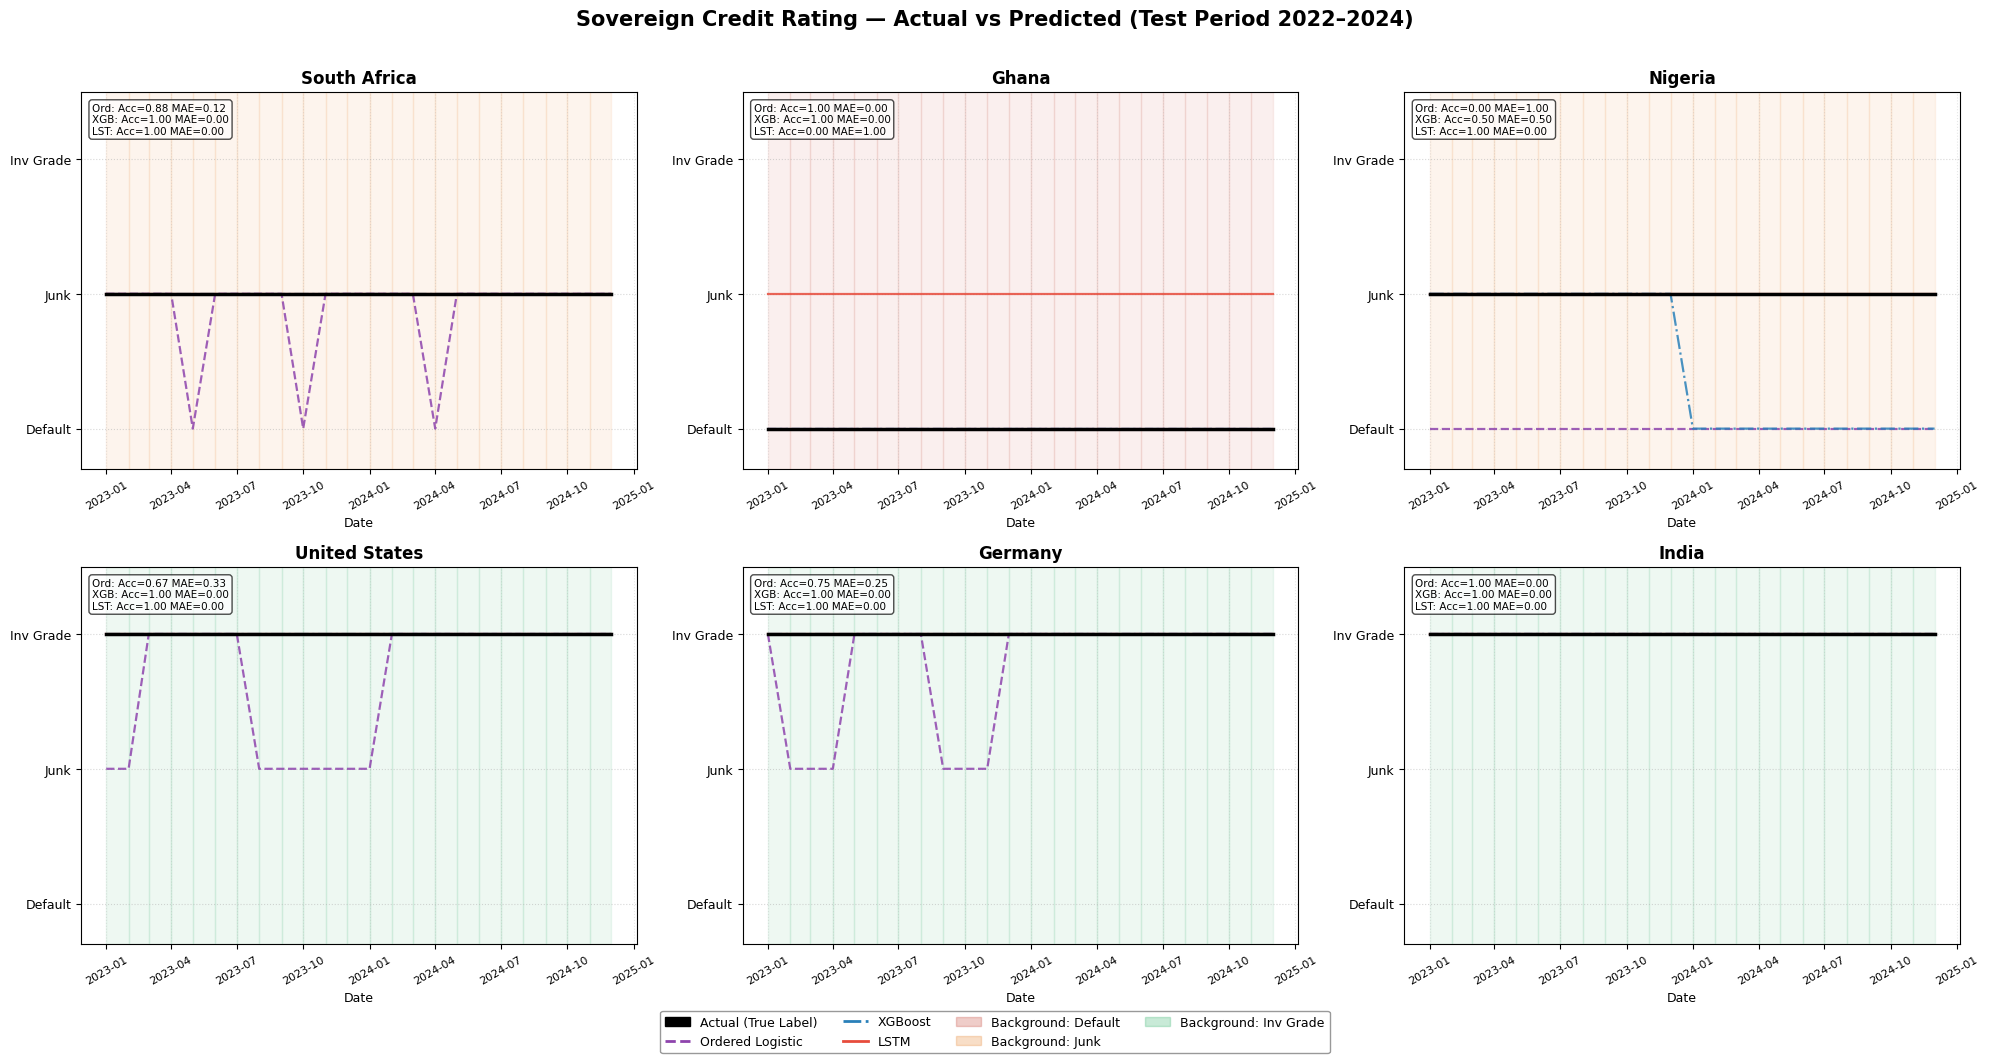

✅ country_predictions_timeseries.png saved


In [74]:
# Plot predictions vs truth for 6 key countries
# Country-level predictions vs truth time series — 6 key countries
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
from pathlib import Path

RESULTS = Path('results')

# 6 representative countries (3 Africa + 3 Benchmark)
PLOT_COUNTRIES = [
    'South Africa', 'Ghana', 'Nigeria',
    'United States', 'Germany', 'India'
]

CLASS_LABELS = {0: 'Default', 1: 'Junk', 2: 'Inv Grade'}
CLASS_COLORS = {0: '#c0392b', 1: '#e67e22', 2: '#27ae60'}

# Confirm which model columns exist
ord_col  = next((c for c in ['pred_ord','pred_ordered_logistic'] if c in df_full.columns), None)
xgb_col  = next((c for c in ['pred_xgb','pred_xgboost']         if c in df_full.columns), None)
lstm_col = next((c for c in ['pred_lstm']                        if c in df_full.columns), None)

available_models = []
if ord_col:  available_models.append((ord_col,  'Ordered Logistic', '#8e44ad', '--'))
if xgb_col:  available_models.append((xgb_col,  'XGBoost',          '#2980b9', '-.'))
if lstm_col: available_models.append((lstm_col, 'LSTM',             '#e74c3c', '-'))

print(f"Models to plot: {[m[1] for m in available_models]}")
print(f"Countries to plot: {PLOT_COUNTRIES}")

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle(
    'Sovereign Credit Rating — Actual vs Predicted (Test Period 2022–2024)',
    fontsize=15, fontweight='bold', y=1.01
)
axes_flat = axes.flatten()

for idx, country in enumerate(PLOT_COUNTRIES):
    ax  = axes_flat[idx]
    df_c = df_full[df_full['country'] == country].copy()
    df_c = df_c.sort_values('date').reset_index(drop=True)

    if df_c.empty:
        ax.text(0.5, 0.5, f'No test data\nfor {country}',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=11, color='gray')
        ax.set_title(country, fontsize=12, fontweight='bold')
        continue

    dates   = pd.to_datetime(df_c['date'])
    y_true  = df_c['future_class'].values

    # ── Shaded background per true class ─────────────────────────────────
    for i in range(len(dates) - 1):
        ax.axvspan(dates.iloc[i], dates.iloc[i+1],
                   alpha=0.08,
                   color=CLASS_COLORS[int(y_true[i])])

    # ── True label as thick step line ─────────────────────────────────────
    ax.step(dates, y_true, where='post',
            color='black', linewidth=2.5, label='Actual', zorder=5)

    # ── Model predictions ─────────────────────────────────────────────────
    for col, name, color, lstyle in available_models:
        if col in df_c.columns and df_c[col].notna().any():
            preds = df_c[col].values.astype(float)
            ax.plot(dates, preds, linestyle=lstyle, color=color,
                    linewidth=1.6, alpha=0.85, label=name, zorder=4)

    # ── Formatting ────────────────────────────────────────────────────────
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['Default', 'Junk', 'Inv Grade'], fontsize=9)
    ax.set_ylim(-0.3, 2.5)
    ax.set_title(country, fontsize=12, fontweight='bold')
    ax.set_xlabel('Date', fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    ax.grid(axis='x', linestyle=':', alpha=0.3)

    # ── Per-country accuracy annotation ──────────────────────────────────
    acc_texts = []
    for col, name, color, _ in available_models:
        if col in df_c.columns and df_c[col].notna().any():
            preds = df_c[col].dropna().values.astype(int)
            truth = df_c.loc[df_c[col].notna(), 'future_class'].values.astype(int)
            acc   = np.mean(preds == truth)
            mae   = np.mean(np.abs(preds - truth))
            acc_texts.append(f'{name[:3]}: Acc={acc:.2f} MAE={mae:.2f}')
    ax.text(0.02, 0.97, '\n'.join(acc_texts),
            transform=ax.transAxes, fontsize=7.5,
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# ── Shared legend ─────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color='black',   label='Actual (True Label)'),
]
for _, name, color, lstyle in available_models:
    legend_handles.append(
        plt.Line2D([0], [0], color=color, linestyle=lstyle,
                   linewidth=2, label=name)
    )
legend_handles += [
    mpatches.Patch(color=CLASS_COLORS[0], alpha=0.25, label='Background: Default'),
    mpatches.Patch(color=CLASS_COLORS[1], alpha=0.25, label='Background: Junk'),
    mpatches.Patch(color=CLASS_COLORS[2], alpha=0.25, label='Background: Inv Grade'),
]
fig.legend(handles=legend_handles, loc='lower center',
           ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.04),
           frameon=True, edgecolor='gray')

plt.tight_layout()
plt.savefig(RESULTS/'country_predictions_timeseries.png', dpi=130,
            bbox_inches='tight')
plt.show()
print('✅ country_predictions_timeseries.png saved')


## 6. ROC Curves (One-vs-Rest)

XGBoost: y_bin=(408, 3), proba=(408, 3)
LSTM: y_bin=(408, 3), proba=(408, 3)


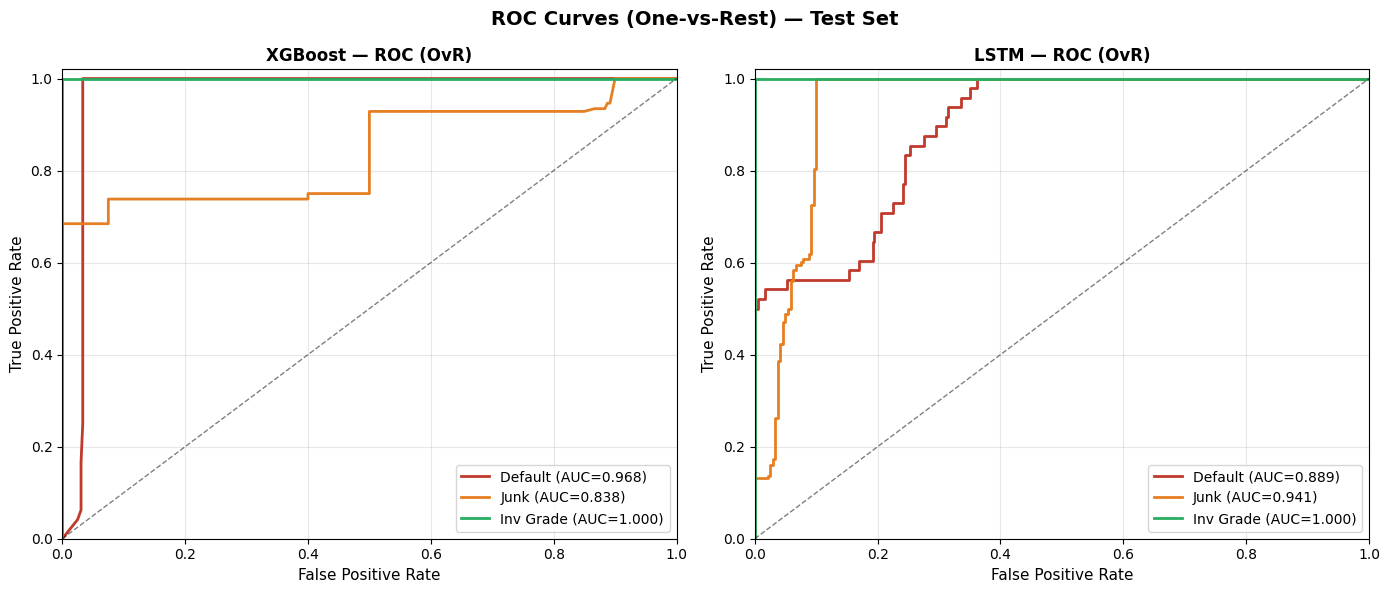

✅ roc_curves.png saved


In [78]:
# FIXED ROC curves — handles shape mismatch between df_full and proba arrays
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

RESULTS = Path('results')
CLASS_NAMES  = ['Default', 'Junk', 'Inv Grade']
class_colors = ['#c0392b', '#e67e22', '#27ae60']

y_true = df_full['future_class'].values.astype(int)
y_bin  = label_binarize(y_true, classes=[0, 1, 2])  # shape (n, 3)

def get_proba_matrix(df, prob_cols):
    """Build (n,3) proba matrix only from rows in df, aligned correctly."""
    arr = df[prob_cols].values.astype(float)
    # If any column is all-NaN, fill with uniform
    for j in range(arr.shape[1]):
        if np.all(np.isnan(arr[:, j])):
            arr[:, j] = 1/3
    arr = np.nan_to_num(arr, nan=1/3)
    # Re-normalize rows to sum to 1
    row_sums = arr.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return arr / row_sums

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('ROC Curves (One-vs-Rest) — Test Set',
             fontsize=14, fontweight='bold')

models_roc = []

# XGBoost
xgb_prob_cols = ['prob_default_xgb', 'prob_junk_xgb', 'prob_invgrade_xgb']
if all(c in df_full.columns for c in xgb_prob_cols):
    models_roc.append(('XGBoost', xgb_prob_cols, axes[0]))

# LSTM
lstm_prob_cols = ['prob_default_lstm', 'prob_junk_lstm', 'prob_invgrade_lstm']
if all(c in df_full.columns for c in lstm_prob_cols):
    models_roc.append(('LSTM', lstm_prob_cols, axes[1]))

# Ordered Logistic
ord_prob_cols = ['prob_default_ord', 'prob_junk_ord', 'prob_invgrade_ord']
if all(c in df_full.columns for c in ord_prob_cols) and len(models_roc) < 2:
    models_roc.append(('Ordered Logistic', ord_prob_cols, axes[len(models_roc)]))

for model_name, prob_cols, ax in models_roc:
    # Drop rows where any prob col is NaN to ensure alignment
    mask = df_full[prob_cols].notna().all(axis=1)
    df_sub  = df_full[mask].copy()
    y_sub   = df_sub['future_class'].values.astype(int)
    y_b     = label_binarize(y_sub, classes=[0, 1, 2])
    proba   = get_proba_matrix(df_sub, prob_cols)

    print(f'{model_name}: y_bin={y_b.shape}, proba={proba.shape}')

    for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, class_colors)):
        if y_b[:, i].sum() == 0:
            print(f'  ⚠️  No positive samples for class {cls_name} — skipping')
            continue
        fpr, tpr, _ = roc_curve(y_b[:, i], proba[:, i])
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f'{cls_name} (AUC={roc_auc:.3f})')

    ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'{model_name} — ROC (OvR)', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(alpha=0.3)

# Hide unused axes
for i in range(len(models_roc), 2):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig(RESULTS/'roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ roc_curves.png saved')


## 7. Final Publication-Ready Summary Table

FINAL MODEL COMPARISON TABLE
                      Model  Accuracy    MAE  F1 (Default)  F1 (Junk)  F1 (Inv.Grade)  Macro F1  Weighted F1  AUC-OvR  Direction Accuracy  Bias Gap MAE
Ordered Logistic Regression    0.5858 0.4142        0.4923     0.4192          0.7879    0.5665       0.6013      NaN                 NaN           NaN
                    XGBoost    0.8529 0.1471        0.6154     0.7826          1.0000    0.7993       0.8652   0.9354              0.8554        0.2778
           LSTM (Attention)    0.9387 0.0613        0.6575     0.9304          1.0000    0.8626       0.9310   0.9435                 NaN           NaN


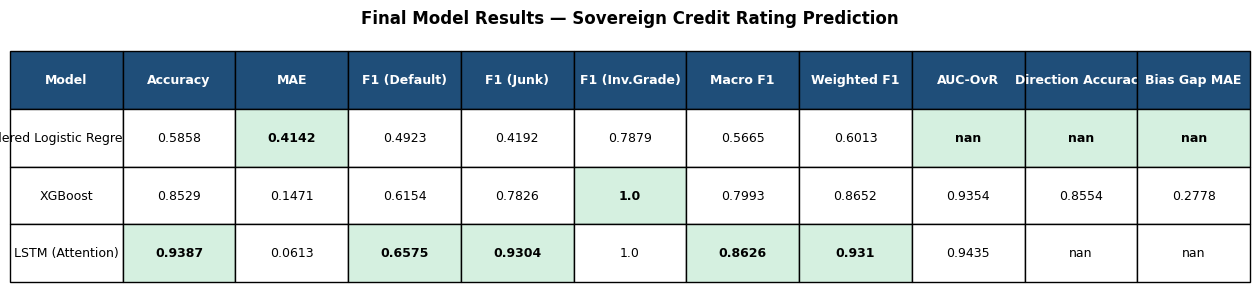

In [79]:
# Load saved CSVs
metrics_df   = pd.read_csv(RESULTS/'full_metrics_table.csv')
bias_df      = pd.read_csv(RESULTS/'bias_analysis.csv')
dir_df       = pd.read_csv(RESULTS/'direction_accuracy.csv')

# Merge all into one table
final_df = metrics_df.merge(dir_df, on='Model', how='left')
final_df = final_df.merge(bias_df[['Model','Bias Gap MAE']], on='Model', how='left')

final_df.to_csv(RESULTS/'final_results_table.csv', index=False)

print('='*80)
print('FINAL MODEL COMPARISON TABLE')
print('='*80)
print(final_df.to_string(index=False))

# Pretty plot of the table
fig, ax = plt.subplots(figsize=(16, 3))
ax.axis('off')
col_labels = final_df.columns.tolist()
cell_text  = final_df.values.tolist()

table = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(9)

# Style header
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#1F4E79')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Highlight best value per numeric column
for j, col in enumerate(col_labels[1:], start=1):
    try:
        vals = [float(row[j]) for row in cell_text if row[j] is not None]
        best_idx = vals.index(max(vals)) if 'Bias' not in col else vals.index(min(vals))
        table[best_idx + 1, j].set_facecolor('#d5f0e0')
        table[best_idx + 1, j].set_text_props(fontweight='bold')
    except:
        pass

plt.title('Final Model Results — Sovereign Credit Rating Prediction',
          fontweight='bold', fontsize=12, pad=20)
plt.savefig(RESULTS/'final_results_table.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Interpretation & Findings

In [77]:
# Final inventory of all result files
import os
print('=== RESULTS DIRECTORY ===')
for f in sorted(Path('results').rglob('*.*')):
    size = os.path.getsize(f) / 1024
    print(f'  {str(f):55s} {size:7.1f} KB')

=== RESULTS DIRECTORY ===
  results/bias_analysis.csv                                   0.1 KB
  results/bias_analysis_plot.png                             73.5 KB
  results/country_predictions_timeseries.png                248.5 KB
  results/direction_accuracy.csv                              0.1 KB
  results/final_results_table.csv                             0.3 KB
  results/final_results_table.png                            68.7 KB
  results/full_metrics_table.csv                              0.3 KB
  results/lstm_best.pt                                       38.7 KB
  results/lstm_training_curve.png                            60.2 KB
  results/model_summary.csv                                   0.1 KB
  results/ordered_logistic_coefficients.csv                   0.3 KB
  results/scaler.pkl                                          1.2 KB
  results/test_predictions.csv                               64.9 KB
  results/xgboost_feature_importance.png                     43.8 KB
  result

## End of pipeline

At this point, the notebook should have produced:
- engineered feature tables
- trained model outputs
- evaluation metrics
- plots / summary artifacts for reporting

This version is intended to be **cleaner and more presentation-ready** than the raw merged notebook.
